In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
ca_vehicles = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_vehicles_final.csv')

print(ca_vehicles.columns.tolist())
print(ca_vehicles.shape)

['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'size', 'type', 'state', 'fuel_mapped', 'avg_msrp', 'depreciation_rate', 'proxy_manufacturer', 'tier', 'demand_score']
(38216, 18)


In [64]:
vehicle_msrp = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/vehicle_msrp_clean.csv')
print(vehicle_msrp.columns.tolist())
print(vehicle_msrp.head())

['Model', 'Year', 'Status', 'Mileage', 'Price', 'make']
                                              Model  Year Status  Mileage  \
0                                  Acura TLX A-Spec  2022    New      NaN   
1                                  Acura RDX A-Spec  2023    New      NaN   
2                                  Acura TLX Type S  2023    New      NaN   
3                                  Acura TLX Type S  2023    New      NaN   
4  Acura MDX Sport Hybrid 3.0L w/Technology Package  2019   Used  32675.0   

     Price   make  
0  49445.0  acura  
1  50895.0  acura  
2  57745.0  acura  
3  57545.0  acura  
4  40990.0  acura  


In [65]:
# filters to realistic price range and recent years, then calculates average price per make per year
msrp_filtered = vehicle_msrp[
    (vehicle_msrp['Price'] >= 15000) &
    (vehicle_msrp['Price'] <= 150000) &
    (vehicle_msrp['Year'] >= 2000)
]

msrp_avg = msrp_filtered.groupby(['make', 'Year'])['Price'].mean().reset_index()
msrp_avg.columns = ['manufacturer', 'year', 'avg_msrp']
msrp_avg['manufacturer'] = msrp_avg['manufacturer'].str.lower()

print(msrp_avg.shape)
print(msrp_avg.head())

(255, 3)
  manufacturer  year      avg_msrp
0        acura  2000  91895.000000
1        acura  2002  44600.000000
2        acura  2006  39995.000000
3        acura  2007  18261.333333
4        acura  2008  16500.000000


In [66]:
print(ca_vehicles[['demand_score', 'depreciation_rate']].corr())

                   demand_score  depreciation_rate
demand_score            1.00000            0.10909
depreciation_rate       0.10909            1.00000


In [67]:
# top 10 highest depreciation - cars losing the most value
top_depreciation = ca_vehicles.groupby(['manufacturer', 'model'])['depreciation_rate'].mean().reset_index()
top_depreciation = top_depreciation.sort_values('depreciation_rate', ascending=False).head(10)
print("Top 10 Highest Depreciation:")
print(top_depreciation)

Top 10 Highest Depreciation:
     manufacturer                    model  depreciation_rate
4509      porsche              macan s awd             0.9899
4938        tesla               model s 75             0.9887
559           bmw            m2 competiton             0.9866
5701        volvo            xc40 momentum             0.9862
4939        tesla  model s 75d - autopilot             0.9855
4948        tesla     model x - auto pilot             0.9854
1497        dodge                neon srt4             0.9848
5711        volvo         xc60 t5 momentum             0.9845
4625          ram         2500 outdoorsman             0.9841
2142         ford      ranger xlt crew cab             0.9835


In [68]:
# top 10 lowest depreciation / highest appreciation - cars holding or gaining value
top_appreciation = ca_vehicles.groupby(['manufacturer', 'model'])['depreciation_rate'].mean().reset_index()
top_appreciation = top_appreciation.sort_values('depreciation_rate', ascending=True).head(10)
print("Top 10 Lowest Depreciation / Highest Appreciation:")
print(top_appreciation)

Top 10 Lowest Depreciation / Highest Appreciation:
     manufacturer                                              model  \
2340          gmc                                    sierra 2500 4wd   
4729        rover                                         lwb 510+hp   
3187         jeep                                    wrangler lj 4x4   
1832         ford            f-350 super duty crew cab xlt 6.7 liter   
1166    chevrolet   silverado 3500 high country drw 4wd 6.6l duramax   
4646          ram  3500 diesel truck 6.7l tradesman 4 door crew c...   
566           bmw                                           m3 sedan   
555           bmw                                                 i8   
1127    chevrolet                                 silverado 2500 4wd   
2348          gmc     sierra 2500 lifted denali 6.6 duramax crew cab   

      depreciation_rate  
2340            -0.9958  
4729            -0.9886  
3187            -0.9815  
1832            -0.9784  
1166            -0.9653  


In [69]:
# filters to realistic depreciation range for everyday vehicles, then finds top 10 highest and lowest
everyday_vehicles = ca_vehicles[
    (ca_vehicles['depreciation_rate'] >= -0.5) &
    (ca_vehicles['depreciation_rate'] <= 0.95)
]

top_depreciation = everyday_vehicles.groupby(['manufacturer', 'model'])['depreciation_rate'].mean().reset_index()
top_depreciation = top_depreciation.sort_values('depreciation_rate', ascending=False).head(10)
print("Top 10 Highest Depreciation:")
print(top_depreciation)

top_appreciation = everyday_vehicles.groupby(['manufacturer', 'model'])['depreciation_rate'].mean().reset_index()
top_appreciation = top_appreciation.sort_values('depreciation_rate', ascending=True).head(10)
print("\nTop 10 Lowest Depreciation / Highest Appreciation:")
print(top_appreciation)

Top 10 Highest Depreciation:
       manufacturer            model  depreciation_rate
3469          mazda          6 wagon             0.9486
602             bmw         x5 3.0si             0.9486
3339          lexus           rc200t             0.9485
2148           ford    van e250 2007             0.9482
2802        hyundai            xg350             0.9478
1307       chrysler  pt cruiser ltd.             0.9467
3723  mercedes-benz       cla 45 amg             0.9447
110            audi     a3 2.0 turbo             0.9446
2             acura        cl type s             0.9439
60            acura    tl 3.2 type s             0.9439

Top 10 Lowest Depreciation / Highest Appreciation:
     manufacturer                                              model  \
1094    chevrolet                 silverado 1500 ltz lifted crew 4wd   
1119    chevrolet            silverado 2500 ltz crew cab 6.6 duramax   
2270          gmc                             sierra 3500hd crew cab   
1848         fo

In [70]:
tier_mapping = {
    'bmw': 'luxury', 'mercedes-benz': 'luxury', 'lexus': 'luxury',
    'audi': 'luxury', 'porsche': 'luxury', 'acura': 'luxury', 'infiniti': 'luxury',
    'toyota': 'economy', 'honda': 'economy', 'hyundai': 'economy',
    'nissan': 'economy', 'kia': 'economy', 'mazda': 'economy', 'subaru': 'economy',
    'chevrolet': 'midrange', 'ford': 'midrange', 'dodge': 'midrange',
    'volkswagen': 'midrange', 'jeep': 'midrange'
}

ca_vehicles['tier'] = ca_vehicles['manufacturer'].map(tier_mapping)
tier_depreciation = ca_vehicles.groupby('tier')['depreciation_rate'].mean().reset_index()
print(tier_depreciation)

       tier  depreciation_rate
0   economy           0.368297
1    luxury           0.280066
2  midrange           0.308458


In [71]:
fuel_depreciation = ca_vehicles.groupby('fuel_mapped')['depreciation_rate'].mean().reset_index()
print(fuel_depreciation)

                fuel_mapped  depreciation_rate
0          battery electric           0.306164
1  diesel and diesel hybrid          -0.114374
2                  gasoline           0.357890
3           hybrid gasoline           0.342172
4                     other           0.069872


In [72]:
# calculates average depreciation rate per manufacturer and sorts from highest to lowest
brand_depreciation = ca_vehicles.groupby('manufacturer')['depreciation_rate'].mean().reset_index()
brand_depreciation = brand_depreciation.sort_values('depreciation_rate', ascending=False)
print(brand_depreciation)

       manufacturer  depreciation_rate
25          mercury           0.837286
29          pontiac           0.788227
33           saturn           0.777923
20       land rover           0.737500
8          chrysler           0.589393
13  harley-davidson           0.524769
5             buick           0.506956
14            honda           0.474324
23            mazda           0.454293
9             dodge           0.417764
34           subaru           0.407007
28           nissan           0.387429
27       mitsubishi           0.364151
10             fiat           0.363357
30          porsche           0.359969
15          hyundai           0.351007
4               bmw           0.339863
37       volkswagen           0.331700
7         chevrolet           0.308181
19              kia           0.305159
11             ford           0.300349
26             mini           0.287836
36           toyota           0.284785
3              audi           0.277768
21            lexus      

In [73]:
# counts how many listings exist per manufacturer to identify brands with sufficient data
print(ca_vehicles['manufacturer'].value_counts())

manufacturer
ford               5085
toyota             4230
chevrolet          3953
honda              2624
nissan             2087
bmw                1822
mercedes-benz      1514
hyundai            1250
ram                1219
lexus              1126
gmc                1073
jeep               1072
volkswagen          977
dodge               957
subaru              881
kia                 848
audi                808
mazda               670
acura               653
cadillac            547
infiniti            508
volvo               465
chrysler            410
mini                363
mitsubishi          283
buick               261
rover               254
lincoln             249
porsche             202
jaguar              162
fiat                117
tesla               112
alfa-romeo          107
saturn               84
pontiac              79
mercury              37
harley-davidson      16
aston-martin          1
land rover            1
Name: count, dtype: int64


In [74]:
# filters to most represented economy and luxury brands then shows top 5 models by listing count
economy_brands = ['toyota', 'honda', 'nissan', 'hyundai', 'ford']
luxury_brands = ['bmw', 'mercedes-benz', 'lexus', 'audi']

economy_models = ca_vehicles[ca_vehicles['manufacturer'].isin(economy_brands)]\
    .groupby(['manufacturer', 'model'])['depreciation_rate'].agg(['mean', 'count'])\
    .reset_index()\
    .sort_values('count', ascending=False)\
    .head(15)

luxury_models = ca_vehicles[ca_vehicles['manufacturer'].isin(luxury_brands)]\
    .groupby(['manufacturer', 'model'])['depreciation_rate'].agg(['mean', 'count'])\
    .reset_index()\
    .sort_values('count', ascending=False)\
    .head(15)

print("Top Economy Models:")
print(economy_models)
print("\nTop Luxury Models:")
print(luxury_models)

Top Economy Models:
     manufacturer    model      mean  count
202          ford    f-150  0.158233    426
713         honda   accord  0.509797    388
781         honda    civic  0.565362    367
1215       nissan   altima  0.609516    352
1530       toyota    camry  0.545095    340
1819       toyota   tacoma  0.087667    312
1574       toyota  corolla  0.600124    256
1888       toyota   tundra -0.126778    211
865         honda     cr-v  0.402204    169
1396       nissan   sentra  0.507616    162
520          ford   fusion  0.616235    162
479          ford    focus  0.721898    157
1127      hyundai   sonata  0.422032    151
111          ford   escape  0.595216    147
550          ford  mustang  0.410911    147

Top Luxury Models:
      manufacturer     model      mean  count
275            bmw      328i  0.602458    130
829  mercedes-benz   c-class  0.357574    117
341            bmw  5 series  0.235436    110
222            bmw  3 series  0.453134    106
21            audi        

In [75]:
print(vehicle_msrp[vehicle_msrp['Model'].str.contains('Prius', case=False, na=False)][['Model', 'Year', 'Price']])

                            Model  Year    Price
94130  Toyota Prius Prime Limited  2022  37340.0
94145             Toyota Prius LE  2022  29303.0
94227  Toyota Prius Prime Limited  2022  37565.0
94259             Toyota Prius LE  2022  29602.0
94275               Toyota Prius   2023  29778.0
...                           ...   ...      ...
99475          Toyota Prius c Two  2016  15999.0
99525        Toyota Prius c Three  2018  25000.0
99595  Toyota Prius Prime Limited  2022  36519.0
99620        Toyota Prius Limited  2022  34724.0
99629          Toyota Prius Three  2016  22790.0

[108 rows x 3 columns]


In [76]:
# calculates average MSRP specifically for Prius models
prius_avg = vehicle_msrp[vehicle_msrp['Model'].str.contains('Prius', case=False, na=False)].groupby('Year')['Price'].mean().reset_index()
prius_avg.columns = ['year', 'prius_avg_msrp']
print(prius_avg)

    year  prius_avg_msrp
0   2012    16590.000000
1   2013    16998.000000
2   2014    15250.000000
3   2015    18646.714286
4   2016    20604.750000
5   2017    23310.400000
6   2018    22348.400000
7   2019    27868.875000
8   2020    28534.571429
9   2021    28995.000000
10  2022    33390.733333
11  2023    34438.000000


In [77]:
# updates avg_msrp for all Prius listings in ca_vehicles using Prius specific averages
prius_mask = ca_vehicles['model'].str.contains('prius', case=False, na=False)

ca_vehicles.loc[prius_mask, 'avg_msrp'] = ca_vehicles.loc[prius_mask, 'year'].map(
    prius_avg.set_index('year')['prius_avg_msrp']
)

# recalculate depreciation rate for prius rows
ca_vehicles.loc[prius_mask, 'depreciation_rate'] = (
    (ca_vehicles.loc[prius_mask, 'avg_msrp'] - ca_vehicles.loc[prius_mask, 'price']) /
    ca_vehicles.loc[prius_mask, 'avg_msrp']
).round(4)

# verify
print(ca_vehicles[prius_mask][['model', 'year', 'price', 'avg_msrp', 'depreciation_rate']].head(10))

                        model  year  price      avg_msrp  depreciation_rate
160                     Prius  2011   6500           NaN                NaN
292   prius four hatchback 4d  2015  15990  18646.714286             0.1425
360              prius hybrid  2010   5900           NaN                NaN
361              prius hybrid  2012   6900  16590.000000             0.5841
1047             prius c four  2018  18995  22348.400000             0.1501
1110                    prius  2017  14500  23310.400000             0.3780
1569       prius prime primum  2017  14990  23310.400000             0.3569
1759                    prius  2005   8495           NaN                NaN
2077                    prius  2010   6800           NaN                NaN
2085              prius three  2011   6580           NaN                NaN


/tmp/ipykernel_1871/2503155153.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_depreciation, x='manufacturer', y='depreciation_rate', palette='coolwarm')


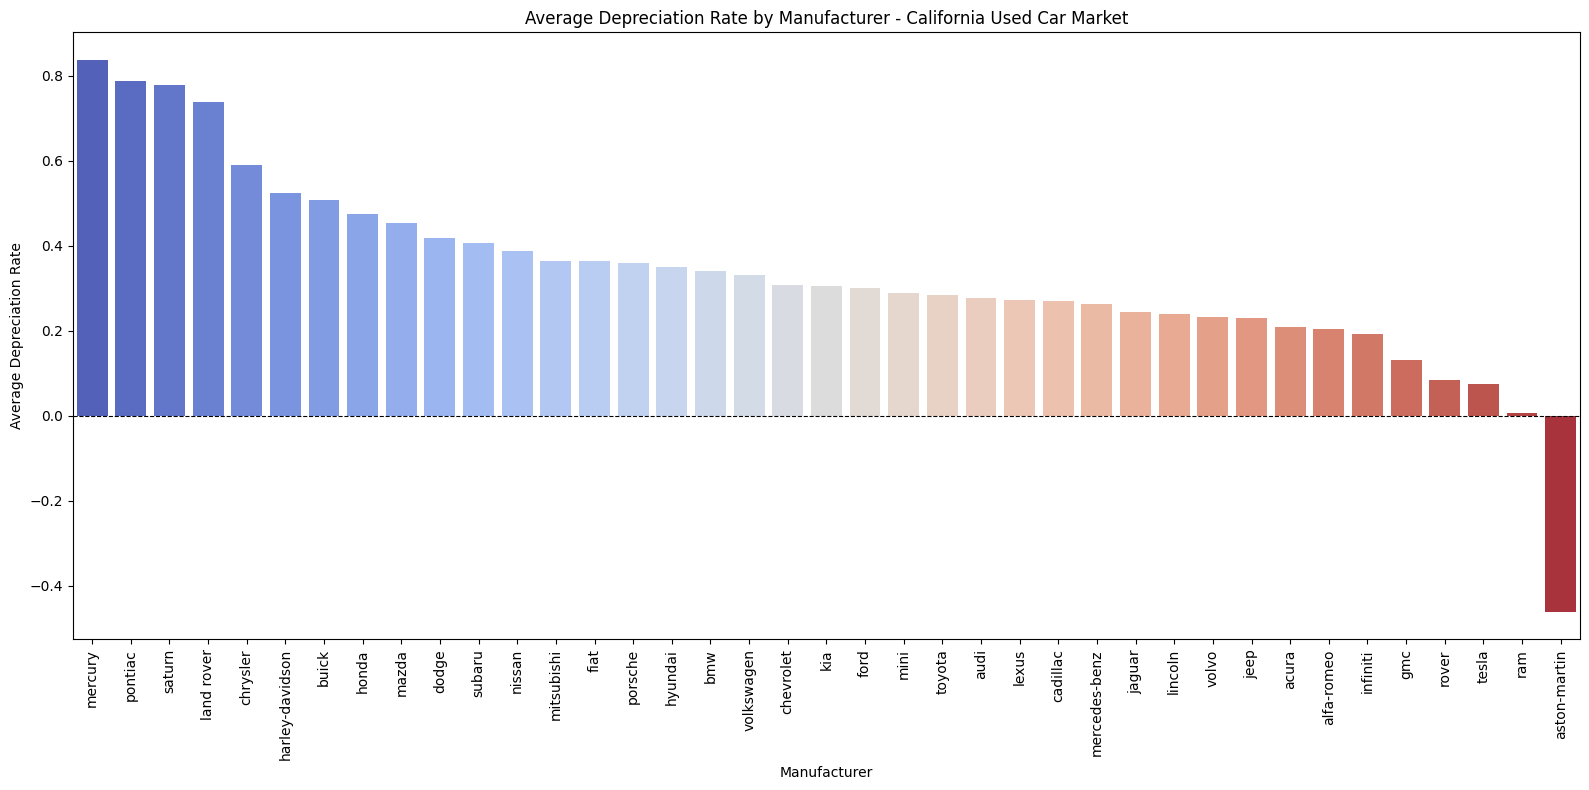

In [78]:
brand_depreciation = ca_vehicles.groupby('manufacturer')['depreciation_rate'].mean().reset_index()
brand_depreciation = brand_depreciation.sort_values('depreciation_rate', ascending=False)

plt.figure(figsize=(16, 8))
sns.barplot(data=brand_depreciation, x='manufacturer', y='depreciation_rate', palette='coolwarm')
plt.title('Average Depreciation Rate by Manufacturer - California Used Car Market')
plt.xlabel('Manufacturer')
plt.ylabel('Average Depreciation Rate')
plt.xticks(rotation=90)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [79]:
print(ca_vehicles.groupby('condition')['price'].mean().sort_values(ascending=False))

condition
new          24561.375000
good         21573.733680
like new     17927.359649
excellent    15902.659007
salvage       4576.633803
fair          3796.415550
Name: price, dtype: float64


In [80]:
print(ca_vehicles.groupby('fuel')['price'].mean().sort_values(ascending=False))

fuel
diesel      32001.705422
other       27048.273890
electric    21195.069536
gas         17050.574306
hybrid      15421.170678
Name: price, dtype: float64


In [81]:
print(ca_vehicles.groupby('region')['price'].mean().sort_values(ascending=False))

region
imperial county     31983.000000
hanford-corcoran    26505.034247
bakersfield         26158.279953
visalia-tulare      24787.901840
santa maria         23433.279379
susanville          21887.572727
monterey bay        21705.417152
santa barbara       21105.051807
redding             20252.432711
reno / tahoe        19773.407057
humboldt county     19757.992157
merced              19653.812865
chico               19373.368885
fresno / madera     19132.830447
SF bay area         18958.390233
gold country        18354.143369
stockton            18331.181227
san luis obispo     18102.407317
orange county       17147.351188
sacramento          16988.889224
san diego           16956.373926
ventura county      16692.442377
modesto             16647.075648
los angeles         16636.534324
mendocino county    16400.308271
yuba-sutter         16038.631978
inland empire       15893.910897
palm springs        14570.996154
siskiyou county      9595.850000
Name: price, dtype: float64


In [82]:
print(ca_vehicles.groupby('condition')['price'].mean().sort_values(ascending=False))
print(ca_vehicles.groupby('fuel')['price'].mean().sort_values(ascending=False))

condition
new          24561.375000
good         21573.733680
like new     17927.359649
excellent    15902.659007
salvage       4576.633803
fair          3796.415550
Name: price, dtype: float64
fuel
diesel      32001.705422
other       27048.273890
electric    21195.069536
gas         17050.574306
hybrid      15421.170678
Name: price, dtype: float64


In [83]:
region_depreciation = ca_vehicles.groupby('region')['depreciation_rate'].mean().reset_index()
region_depreciation = region_depreciation.sort_values('depreciation_rate', ascending=False)
print(region_depreciation)

              region  depreciation_rate
23   siskiyou county           0.613271
15      palm springs           0.439666
8      inland empire           0.405611
9        los angeles           0.384407
28       yuba-sutter           0.382829
12           modesto           0.369972
26    ventura county           0.368276
14     orange county           0.364922
19         san diego           0.360488
18        sacramento           0.345035
4       gold country           0.336658
10  mendocino county           0.324697
20   san luis obispo           0.318699
24          stockton           0.312824
0        SF bay area           0.306699
3    fresno / madera           0.287220
2              chico           0.279370
11            merced           0.270414
17      reno / tahoe           0.256132
21     santa barbara           0.249903
13      monterey bay           0.249888
16           redding           0.237151
6    humboldt county           0.228327
22       santa maria           0.178238


/tmp/ipykernel_1871/2636333854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_depreciation, x='depreciation_rate', y='region', palette='coolwarm')


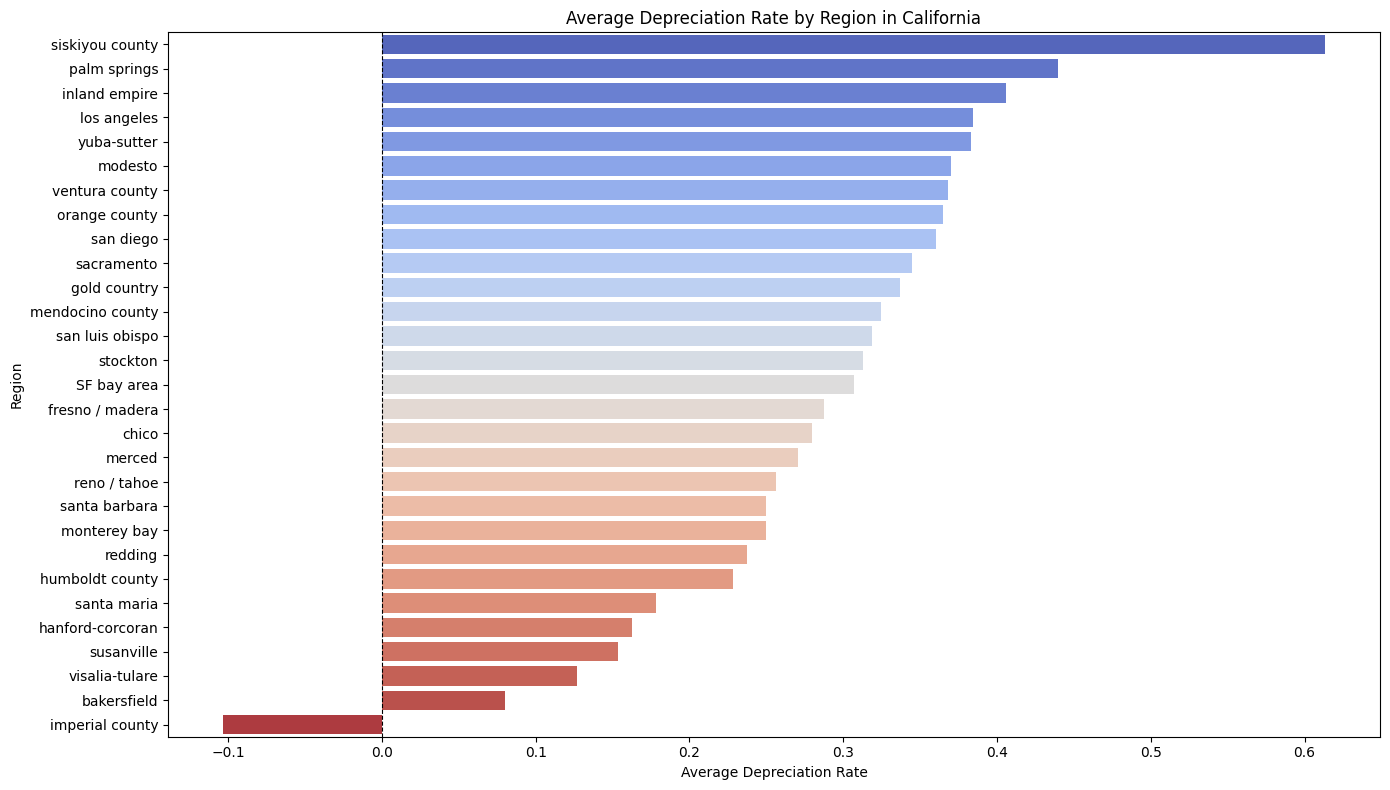

In [84]:
plt.figure(figsize=(14, 8))
sns.barplot(data=region_depreciation, x='depreciation_rate', y='region', palette='coolwarm')
plt.title('Average Depreciation Rate by Region in California')
plt.xlabel('Average Depreciation Rate')
plt.ylabel('Region')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [85]:
everyday_vehicles = ca_vehicles[
    (ca_vehicles['depreciation_rate'] >= -0.5) &
    (ca_vehicles['depreciation_rate'] <= 0.95)
]

top_depreciation = everyday_vehicles.groupby(['manufacturer', 'model'])['depreciation_rate'].mean().reset_index()
top_depreciation = top_depreciation.sort_values('depreciation_rate', ascending=False).head(10)
top_depreciation['vehicle'] = top_depreciation['manufacturer'] + ' ' + top_depreciation['model']

top_appreciation = everyday_vehicles.groupby(['manufacturer', 'model'])['depreciation_rate'].mean().reset_index()
top_appreciation = top_appreciation.sort_values('depreciation_rate', ascending=True).head(10)
top_appreciation['vehicle'] = top_appreciation['manufacturer'] + ' ' + top_appreciation['model']

In [86]:
top_depreciation['vehicle'] = (top_depreciation['manufacturer'] + ' ' + top_depreciation['model']).str[:25]
top_appreciation['vehicle'] = (top_appreciation['manufacturer'] + ' ' + top_appreciation['model']).str[:25]

/tmp/ipykernel_1871/1078670242.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_depreciation, x='vehicle', y='depreciation_rate', palette='Reds_r', ax=axes[0])
/tmp/ipykernel_1871/1078670242.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_appreciation, x='vehicle', y='depreciation_rate', palette='Greens_r', ax=axes[1])


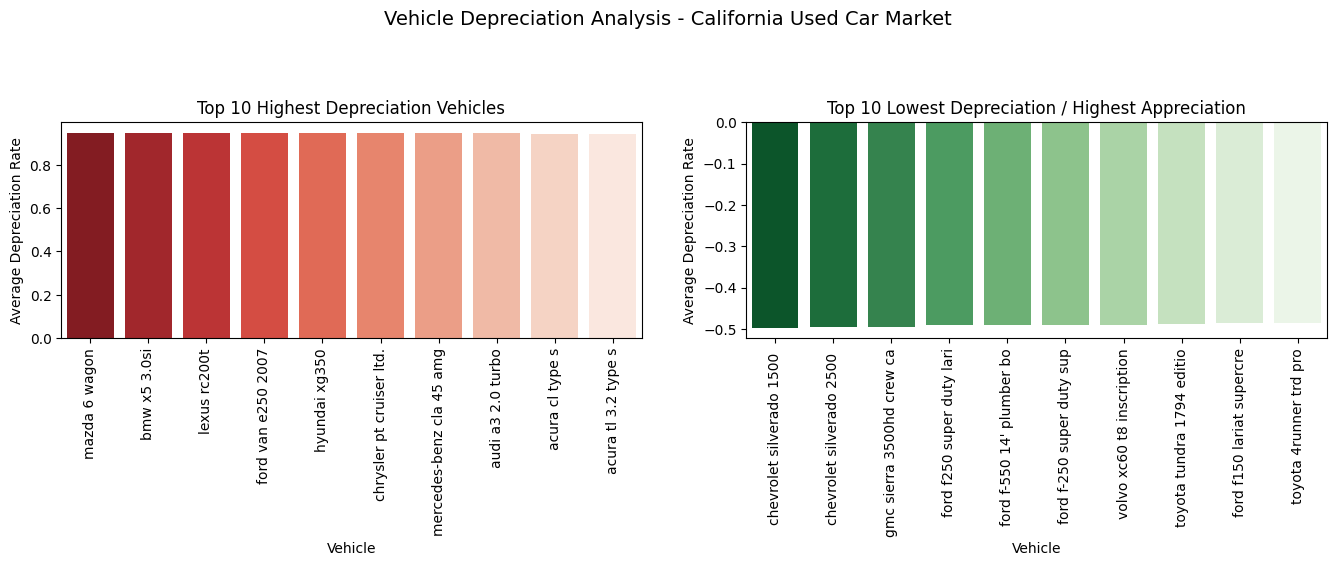

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=top_depreciation, x='vehicle', y='depreciation_rate', palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Highest Depreciation Vehicles')
axes[0].set_xlabel('Vehicle')
axes[0].set_ylabel('Average Depreciation Rate')
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(data=top_appreciation, x='vehicle', y='depreciation_rate', palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Lowest Depreciation / Highest Appreciation')
axes[1].set_xlabel('Vehicle')
axes[1].set_ylabel('Average Depreciation Rate')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle('Vehicle Depreciation Analysis - California Used Car Market', fontsize=14)
plt.tight_layout(pad=3.0)
plt.show()

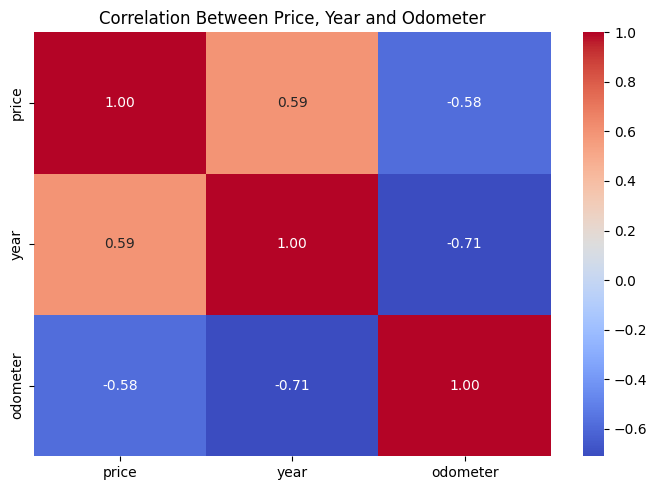

In [88]:
# calculates correlation between price, year and odometer then visualizes it as a heatmap
correlation = ca_vehicles[['price', 'year', 'odometer']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Price, Year and Odometer')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1871/521728136.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=condition_price, x='condition', y='price', palette='Blues_r', ax=axes[0])
/tmp/ipykernel_1871/521728136.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fuel_price, x='fuel', y='price', palette='Greens_r', ax=axes[1])


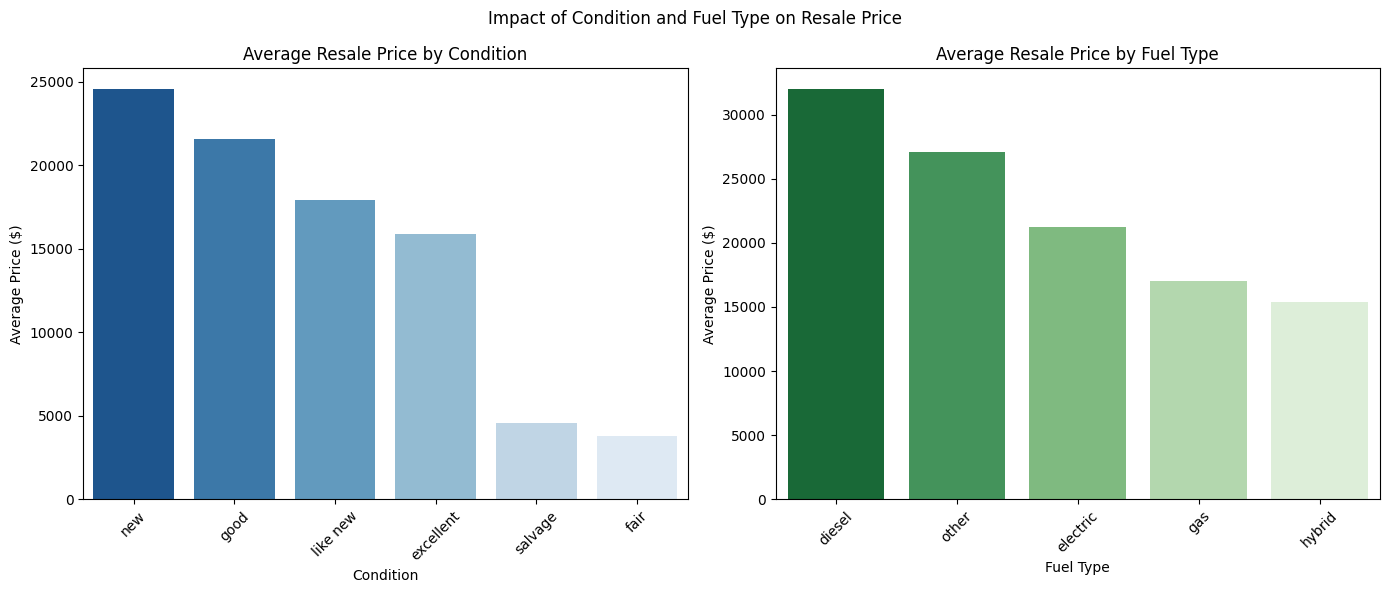

In [89]:
# average price by condition
condition_price = ca_vehicles.groupby('condition')['price'].mean().reset_index()
condition_price = condition_price.sort_values('price', ascending=False)

# average price by fuel type
fuel_price = ca_vehicles.groupby('fuel')['price'].mean().reset_index()
fuel_price = fuel_price.sort_values('price', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=condition_price, x='condition', y='price', palette='Blues_r', ax=axes[0])
axes[0].set_title('Average Resale Price by Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Average Price ($)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=fuel_price, x='fuel', y='price', palette='Greens_r', ax=axes[1])
axes[1].set_title('Average Resale Price by Fuel Type')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Average Price ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Impact of Condition and Fuel Type on Resale Price', fontsize=12)
plt.tight_layout()
plt.show()

In [90]:
# calculates average price of trucks specifically by region
truck_by_region = ca_vehicles[ca_vehicles['type'] == 'truck'].groupby('region')['price'].mean().reset_index()
truck_by_region = truck_by_region.sort_values('price', ascending=False)
print(truck_by_region)

              region         price
5   hanford-corcoran  43000.000000
1        bakersfield  29662.889503
20   san luis obispo  28475.442308
27    visalia-tulare  28248.153846
15      palm springs  28073.175439
0        SF bay area  26733.241758
21     santa barbara  26507.309524
24          stockton  26039.711864
17      reno / tahoe  25851.945736
2              chico  25583.900000
3    fresno / madera  25547.522581
22       santa maria  25105.600000
16           redding  24778.719512
26    ventura county  24020.031250
6    humboldt county  23928.863636
18        sacramento  23617.680851
14     orange county  21721.489051
13      monterey bay  21540.660377
19         san diego  20768.130952
8      inland empire  20005.173469
28       yuba-sutter  19065.716667
12           modesto  18760.736842
9        los angeles  17095.972973
7    imperial county  16125.000000
4       gold country  14156.666667
23   siskiyou county  13823.500000
10  mendocino county  12549.200000
11            merced

In [91]:
print(ca_vehicles['type'].value_counts())
print(ca_vehicles['type'].nunique())
print(ca_vehicles['type'].isnull().sum())

type
sedan          10002
SUV             6494
pickup          3843
hatchback       2306
other           2280
truck           1954
coupe           1817
wagon           1056
van              827
convertible      754
mini-van         338
offroad           54
bus               21
Name: count, dtype: int64
13
6470


In [92]:
# reloads and stacks all 6 years of registration data
!pip install pgeocode
import pgeocode


reg_2024 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-counts-2024.csv')
reg_2024['year'] = 2024
reg_2023 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-20231.csv')
reg_2023['year'] = 2023
reg_2022 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2022.csv')
reg_2022['year'] = 2022
reg_2021 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2021.csv')
reg_2021['year'] = 2021
reg_2020 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-count-as-of-1-1-2020.csv')
reg_2020['year'] = 2020
reg_2019 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code.csv')
reg_2019['year'] = 2019

reg_2023.rename(columns={'ZIP Code': 'Zip Code'}, inplace=True)
reg_2024.rename(columns={'ZIP Code': 'Zip Code'}, inplace=True)

complete_reg = pd.concat([reg_2019, reg_2020, reg_2021, reg_2022, reg_2023, reg_2024], ignore_index=True)
complete_reg['Make'] = complete_reg['Make'].str.lower()
complete_reg['Fuel'] = complete_reg['Fuel'].str.lower()

print(complete_reg.shape)

/tmp/ipykernel_1871/1197587432.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2022 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2022.csv')
/tmp/ipykernel_1871/1197587432.py:12: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2021 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2021.csv')
/tmp/ipykernel_1871/1197587432.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2020 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-count-as-of-1-1-2020.csv')
/tmp/ipykernel_1871/1197587432.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2019 = pd.read_csv('/content/drive/MyDrive/Sen

(3632393, 8)


In [93]:
# maps zipcodes to california regions using pgeocode
nomi = pgeocode.Nominatim('us')
unique_zips = complete_reg['Zip Code'].unique().tolist()

results = []
for zip_code in unique_zips:
    try:
        result = nomi.query_postal_code(str(zip_code))
        if result['state_code'] == 'CA':
            results.append({
                'Zip Code': zip_code,
                'city': result['place_name'],
                'county': result['county_name'],
                'state': result['state_code']
            })
    except:
        pass

ca_zip_mapping = pd.DataFrame(results)

county_to_region = {
    'Los Angeles': 'los angeles',
    'San Diego': 'san diego',
    'Orange': 'orange county',
    'San Bernardino': 'inland empire',
    'Riverside': 'inland empire',
    'Santa Clara': 'SF bay area',
    'Alameda': 'SF bay area',
    'Contra Costa': 'SF bay area',
    'Marin': 'SF bay area',
    'San Mateo': 'SF bay area',
    'City and County of San Francisco': 'SF bay area',
    'Santa Cruz': 'SF bay area',
    'Napa': 'SF bay area',
    'Solano': 'SF bay area',
    'Sonoma': 'SF bay area',
    'Sacramento': 'sacramento',
    'Yolo': 'sacramento',
    'Placer': 'sacramento',
    'El Dorado': 'gold country',
    'Amador': 'gold country',
    'Calaveras': 'gold country',
    'Tuolumne': 'gold country',
    'Mariposa': 'gold country',
    'Nevada': 'gold country',
    'Sierra': 'gold country',
    'Alpine': 'gold country',
    'Fresno': 'fresno / madera',
    'Madera': 'fresno / madera',
    'Kern': 'bakersfield',
    'Ventura': 'ventura county',
    'Santa Barbara': 'santa barbara',
    'San Luis Obispo': 'san luis obispo',
    'Monterey': 'monterey bay',
    'San Benito': 'monterey bay',
    'San Joaquin': 'stockton',
    'Stanislaus': 'modesto',
    'Merced': 'merced',
    'Tulare': 'visalia-tulare',
    'Kings': 'hanford-corcoran',
    'Humboldt': 'humboldt county',
    'Trinity': 'humboldt county',
    'Del Norte': 'humboldt county',
    'Mendocino': 'mendocino county',
    'Lake': 'mendocino county',
    'Shasta': 'redding',
    'Tehama': 'redding',
    'Butte': 'chico',
    'Glenn': 'chico',
    'Colusa': 'chico',
    'Yuba': 'yuba-sutter',
    'Sutter': 'yuba-sutter',
    'Lassen': 'susanville',
    'Plumas': 'susanville',
    'Siskiyou': 'siskiyou county',
    'Modoc': 'siskiyou county',
    'Imperial': 'imperial county',
    'Inyo': 'palm springs',
    'Mono': 'palm springs',
}

ca_zip_mapping['region'] = ca_zip_mapping['county'].map(county_to_region)
ca_zip_mapping['Zip Code'] = ca_zip_mapping['Zip Code'].astype(str)
complete_reg['Zip Code'] = complete_reg['Zip Code'].astype(str)

complete_reg = complete_reg.merge(ca_zip_mapping[['Zip Code', 'region']], on='Zip Code', how='left')
complete_reg = complete_reg.dropna(subset=['region'])

print(complete_reg['region'].value_counts())

region
los angeles         1563303
SF bay area         1420161
inland empire        746576
san diego            568866
orange county        543879
sacramento           250308
fresno / madera      212546
bakersfield          165570
ventura county       156816
stockton             141932
gold country         122776
monterey bay         107338
modesto              103216
santa barbara         97984
visalia-tulare        94064
san luis obispo       81030
humboldt county       69141
mendocino county      66898
merced                60778
imperial county       41078
chico                 35775
redding               35475
hanford-corcoran      24370
yuba-sutter           22194
palm springs          18008
siskiyou county       16677
susanville            13870
Name: count, dtype: int64


In [94]:
# calculates demand score per region, make and fuel type
# total registered is the number of registered vehicles of each unique combination of (region + make + fuel)
demand = complete_reg.groupby(['region', 'Make', 'Fuel'])['Vehicles'].sum().reset_index()
demand.columns = ['region', 'make', 'fuel', 'total_registered']
demand['demand_score'] = demand['total_registered'] / demand['total_registered'].max()

print(demand.shape)
print(demand.head())

(3850, 5)
        region               make                      fuel  total_registered  \
0  SF bay area              acura                  gasoline           1222456   
1  SF bay area         alfa romeo                  gasoline               858   
2  SF bay area  american lafrance  diesel and diesel hybrid               306   
3  SF bay area  american lafrance                  gasoline               156   
4  SF bay area  american lafrance               natural gas               228   

   demand_score  
0      0.087265  
1      0.000061  
2      0.000022  
3      0.000011  
4      0.000016  


In [95]:
# saves demand lookup table so Flask API can automatically calculate demand score for user inputs
demand.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/demand_lookup.csv', index=False)
print("Demand lookup saved")
print(demand.shape)

Demand lookup saved
(3850, 5)


In [96]:
# maps fuel types to match registration data naming
fuel_mapping = {
    'gas': 'gasoline',
    'diesel': 'diesel and diesel hybrid',
    'electric': 'battery electric',
    'hybrid': 'hybrid gasoline',
    'other': 'other'
}

ca_vehicles['fuel_mapped'] = ca_vehicles['fuel'].map(fuel_mapping)
ca_vehicles['manufacturer'] = ca_vehicles['manufacturer'].str.lower()
demand['make'] = demand['make'].str.lower()
demand['fuel'] = demand['fuel'].str.lower()

# drop old empty demand score column
ca_vehicles = ca_vehicles.drop(columns=['demand_score'])

ca_vehicles = ca_vehicles.merge(
    demand[['region', 'make', 'fuel', 'demand_score']],
    left_on=['region', 'manufacturer', 'fuel_mapped'],
    right_on=['region', 'make', 'fuel'],
    how='left'
)

ca_vehicles = ca_vehicles.drop(columns=['make', 'fuel_y'], errors='ignore')
ca_vehicles = ca_vehicles.rename(columns={'fuel_x': 'fuel'}) if 'fuel_x' in ca_vehicles.columns else ca_vehicles

# fill nulls
ca_vehicles['demand_score'] = ca_vehicles.groupby(['region', 'fuel_mapped'])['demand_score'].transform(lambda x: x.fillna(x.mean()))
ca_vehicles['demand_score'] = ca_vehicles['demand_score'].fillna(0)

print(ca_vehicles['demand_score'].isnull().sum())
print(ca_vehicles['demand_score'].describe())

0
count    38216.000000
mean         0.056298
std          0.130785
min          0.000000
25%          0.000875
50%          0.009206
75%          0.045540
max          1.000000
Name: demand_score, dtype: float64


In [97]:
# save the zipcode mapping so you dont have to rerun the loop every session
ca_zip_mapping.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_zip_mapping.csv', index=False)

In [98]:
# verify everything looks good before saving
print(ca_vehicles.shape)
print(ca_vehicles['demand_score'].isnull().sum())
print(ca_vehicles['depreciation_rate'].isnull().sum())
print(ca_vehicles['avg_msrp'].isnull().sum())

# save
ca_vehicles.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_vehicles_final.csv', index=False)
print("Saved successfully")

(38216, 18)
0
225
225
Saved successfully


In [99]:
# compares price of the same truck make across different regions
truck_analysis = ca_vehicles[ca_vehicles['type'].isin(['truck', 'pickup'])].groupby(
    ['manufacturer', 'region'])['price'].agg(['mean', 'count']).reset_index()
truck_analysis.columns = ['manufacturer', 'region', 'avg_price', 'listing_count']
truck_analysis = truck_analysis[truck_analysis['listing_count'] >= 5]

# focus on top truck brands
top_truck_brands = ['ford', 'chevrolet', 'ram', 'gmc', 'toyota']
truck_analysis = truck_analysis[truck_analysis['manufacturer'].isin(top_truck_brands)]

print(truck_analysis.sort_values(['manufacturer', 'avg_price'], ascending=[True, False]))

    manufacturer            region     avg_price  listing_count
9      chevrolet   imperial county  45645.500000             10
29     chevrolet    visalia-tulare  36756.966667             30
19     chevrolet      reno / tahoe  32961.693182             88
7      chevrolet  hanford-corcoran  31054.000000              5
3      chevrolet       bakersfield  31015.069767             86
..           ...               ...           ...            ...
240       toyota     orange county  24649.545455             44
232       toyota   humboldt county  23720.419355             31
244       toyota        sacramento  23549.200000             65
235       toyota       los angeles  20702.913043             46
226       toyota       SF bay area  19246.594595             37

[130 rows x 4 columns]


In [100]:
print(ca_vehicles.shape)
print(ca_vehicles.isnull().sum())

(38216, 18)
region                    0
price                     0
year                      0
manufacturer           1109
model                   226
condition             10944
fuel                     42
odometer                  0
title_status           1156
size                  28429
type                   6470
state                     0
fuel_mapped              42
avg_msrp                225
depreciation_rate       225
proxy_manufacturer     1109
tier                   6949
demand_score              0
dtype: int64


In [101]:
# drops columns not needed for modeling
ca_vehicles_model = ca_vehicles.drop(columns=[
    'size',              # 74% missing, not useful
    'state',             # all california, no variation
    'fuel_mapped',       # duplicate of fuel
    'proxy_manufacturer',# only needed for msrp calculation
    'tier',              # too many nulls, redundant with manufacturer
    'model',             # too many unique values, too messy
    'title_status',      # high nulls, less relevant
])

print(ca_vehicles_model.columns.tolist())
print(ca_vehicles_model.shape)

['region', 'price', 'year', 'manufacturer', 'condition', 'fuel', 'odometer', 'type', 'avg_msrp', 'depreciation_rate', 'demand_score']
(38216, 11)


In [102]:
# fills categorical nulls with unknown and drops remaining numeric nulls
ca_vehicles_model['condition'] = ca_vehicles_model['condition'].fillna('unknown')
ca_vehicles_model['type'] = ca_vehicles_model['type'].fillna('other')
ca_vehicles_model['manufacturer'] = ca_vehicles_model['manufacturer'].fillna('unknown')
ca_vehicles_model['fuel'] = ca_vehicles_model['fuel'].fillna('other')

# drop rows where avg_msrp and depreciation_rate are still null
ca_vehicles_model = ca_vehicles_model.dropna(subset=['avg_msrp', 'depreciation_rate'])

print(ca_vehicles_model.isnull().sum())
print(ca_vehicles_model.shape)

region               0
price                0
year                 0
manufacturer         0
condition            0
fuel                 0
odometer             0
type                 0
avg_msrp             0
depreciation_rate    0
demand_score         0
dtype: int64
(37991, 11)


In [103]:
from sklearn.preprocessing import LabelEncoder
import joblib

# creates and saves a separate encoder for each categorical column
label_encoders = {}
cat_cols = ['region', 'manufacturer', 'condition', 'fuel', 'type']

for col in cat_cols:
    le = LabelEncoder()
    ca_vehicles_model[col] = le.fit_transform(ca_vehicles_model[col])
    label_encoders[col] = le

joblib.dump(label_encoders, '/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/label_encoders.pkl')
print("Encoders saved successfully")
print(list(label_encoders.keys()))
print(ca_vehicles_model.head())
print(ca_vehicles_model.dtypes)

Encoders saved successfully
['region', 'manufacturer', 'condition', 'fuel', 'type']
   region  price  year  manufacturer  condition  fuel  odometer  type  \
0       1  16990  2018            15          2     2   16930.0     9   
1       1   3700  2004            36          2     2  142000.0     7   
2       1  11975  2003            13          0     2  207000.0     8   
3       1  21950  2003             7          0     0  202537.0    10   
4       1  27590  2018             0          2     2   20420.0     9   

       avg_msrp  depreciation_rate  demand_score  
0  19570.490421             0.1319      0.010784  
1  27233.645733             0.8641      0.075758  
2  30181.390204             0.6032      0.029806  
3  24663.333333             0.1100      0.002226  
4  26767.297424            -0.0307      0.003914  
region                 int64
price                  int64
year                   int64
manufacturer           int64
condition              int64
fuel                   int

In [104]:
# removes price derived features to prevent data leakage
X = ca_vehicles_model.drop(columns=['price', 'avg_msrp', 'depreciation_rate'])
y = ca_vehicles_model['price']

print(X.columns.tolist())
print(X.shape)
print(y.shape)

['region', 'year', 'manufacturer', 'condition', 'fuel', 'odometer', 'type', 'demand_score']
(37991, 8)
(37991,)


In [105]:
from sklearn.model_selection import train_test_split

# splits data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training rows: {X_train.shape[0]}')
print(f'Testing rows: {X_test.shape[0]}')

Training rows: 30392
Testing rows: 7599


In [106]:
from xgboost import XGBRegressor
import joblib

# trains xgboost with sensible default parameters
model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
joblib.dump(model, '/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/xgboost_model.pkl')
print("Model trained successfully")

Model trained successfully


In [107]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: ${rmse:,.2f}')
print(f'R2 Score: {r2:.4f}')

RMSE: $5,891.49
R2 Score: 0.7790


/tmp/ipykernel_1871/3896564433.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='coolwarm')


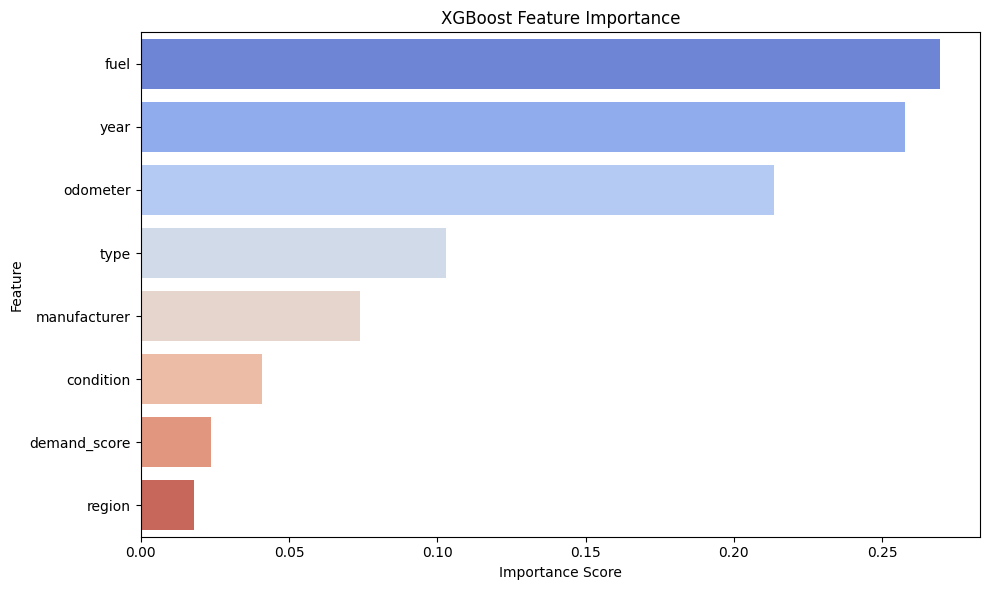

In [108]:
import matplotlib.pyplot as plt

# shows which features the model relied on most
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='coolwarm')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [109]:
ca_vehicles_model.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_vehicles_model.csv', index=False)
print("Saved successfully")

Saved successfully


In [110]:
import joblib
joblib.dump(model, '/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/xgboost_model.pkl')
print("Model saved successfully")

Model saved successfully


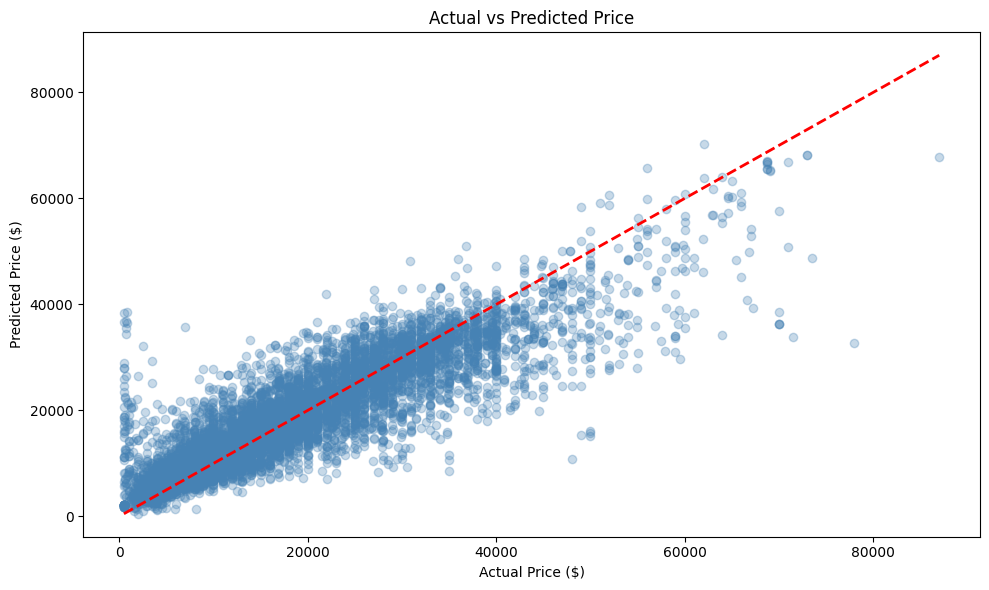

In [111]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.tight_layout()
plt.show()

In [112]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# selects features that best represent depreciation behavior
cluster_features = ca_vehicles[['avg_msrp', 'depreciation_rate', 'odometer', 'year']].dropna()

# standardizes features so no single feature dominates due to scale differences
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

print(cluster_scaled.shape)

(37991, 4)


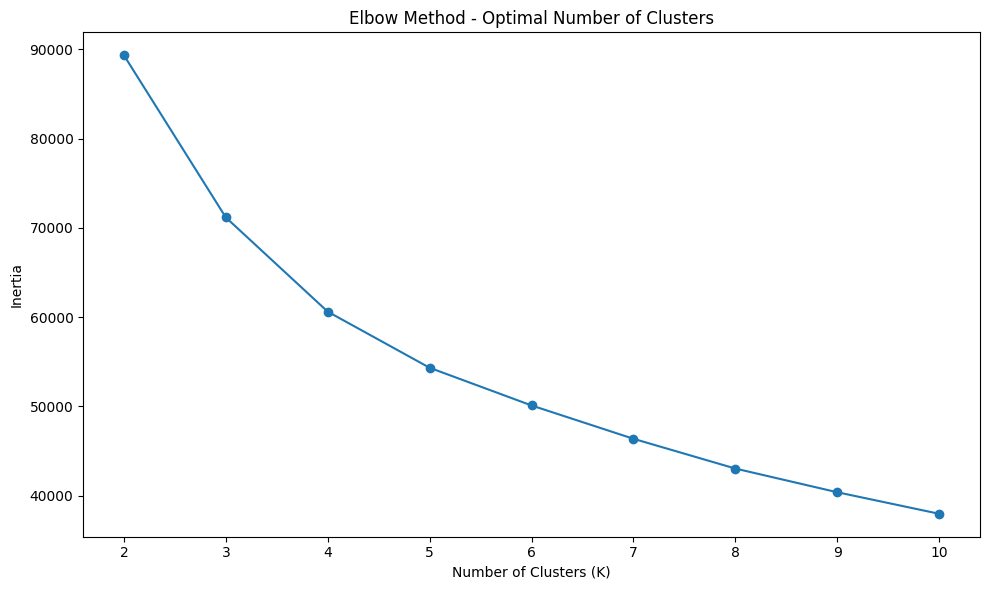

In [113]:
# tests different values of k and plots inertia to find the optimal number of clusters
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [ ]:
# trains k-means with 5 clusters on the scaled depreciation features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_features['cluster'] = kmeans.fit_predict(cluster_scaled)

print(cluster_features['cluster'].value_counts())

In [ ]:
cluster_summary = cluster_features.groupby('cluster')[['avg_msrp', 'depreciation_rate', 'odometer', 'year']].mean().reset_index()
cluster_summary = cluster_summary.sort_values('depreciation_rate')
print(cluster_summary)

In [116]:
print(ca_vehicles['manufacturer'].unique().tolist())
print(ca_vehicles['condition'].unique().tolist())
print(ca_vehicles['fuel'].unique().tolist())
print(ca_vehicles['type'].unique().tolist())
print(ca_vehicles['region'].unique().tolist())

['hyundai', 'toyota', 'harley-davidson', 'chevrolet', 'acura', 'volkswagen', 'gmc', 'subaru', 'mini', 'audi', 'ford', 'pontiac', 'lexus', 'nissan', 'chrysler', 'honda', 'mercedes-benz', 'ram', 'jeep', 'kia', 'bmw', 'mazda', 'tesla', 'fiat', 'cadillac', nan, 'dodge', 'infiniti', 'lincoln', 'alfa-romeo', 'mitsubishi', 'volvo', 'buick', 'porsche', 'jaguar', 'rover', 'mercury', 'saturn', 'aston-martin', 'land rover']
['good', 'excellent', nan, 'new', 'like new', 'fair', 'salvage']
['gas', 'diesel', 'other', 'electric', 'hybrid', nan]
['sedan', nan, 'pickup', 'truck', 'other', 'hatchback', 'SUV', 'coupe', 'van', 'offroad', 'convertible', 'wagon', 'mini-van', 'bus']
['bakersfield', 'chico', 'fresno / madera', 'gold country', 'hanford-corcoran', 'humboldt county', 'imperial county', 'inland empire', 'los angeles', 'mendocino county', 'merced', 'modesto', 'monterey bay', 'orange county', 'palm springs', 'redding', 'reno / tahoe', 'sacramento', 'san diego', 'san luis obispo', 'santa barbara', '

/tmp/ipykernel_1871/2632432768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='coolwarm')


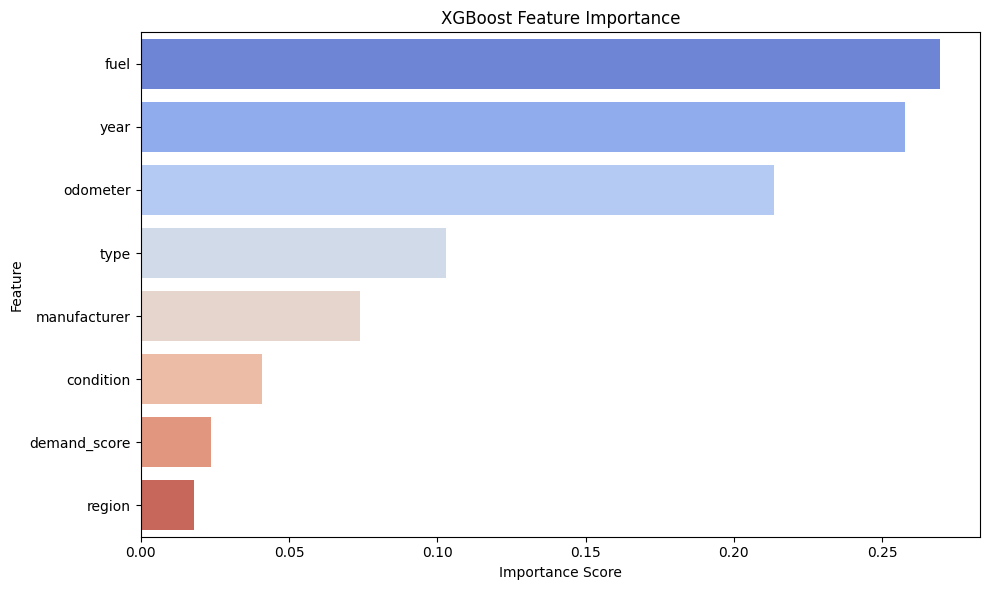

In [117]:
# save feature importance chart
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='coolwarm')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')

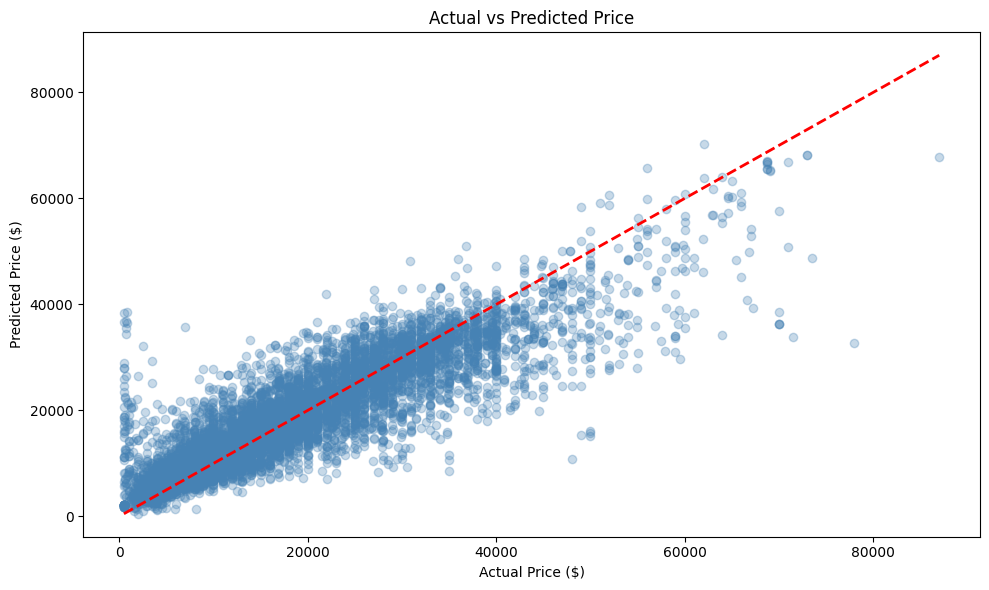

In [118]:
# save actual vs predicted chart
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight', facecolor='white')

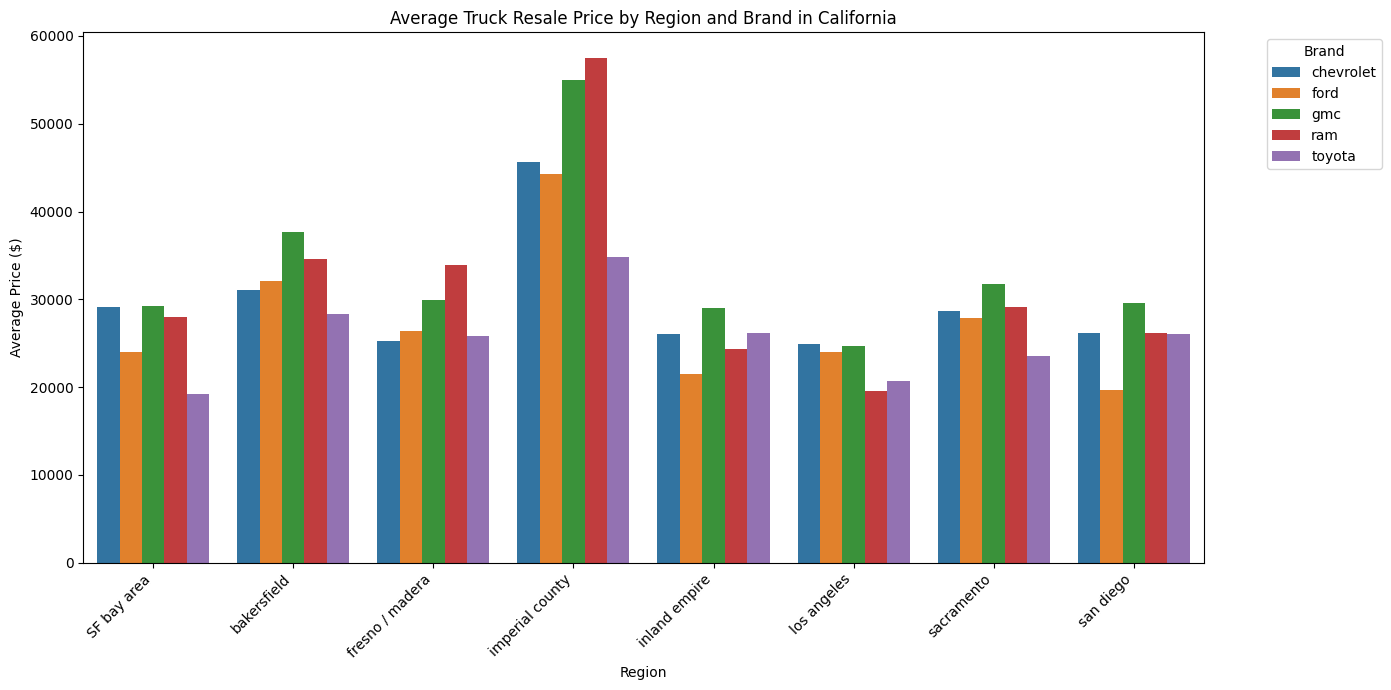

In [119]:
# top 5 truck brands across key california regions
top_truck_brands = ['ford', 'chevrolet', 'ram', 'gmc', 'toyota']
key_regions = ['los angeles', 'SF bay area', 'bakersfield', 'inland empire',
               'san diego', 'imperial county', 'sacramento', 'fresno / madera']

truck_regional = ca_vehicles[
    (ca_vehicles['type'].isin(['truck', 'pickup'])) &
    (ca_vehicles['manufacturer'].isin(top_truck_brands)) &
    (ca_vehicles['region'].isin(key_regions))
].groupby(['region', 'manufacturer'])['price'].mean().reset_index()

truck_regional.columns = ['region', 'manufacturer', 'avg_price']

plt.figure(figsize=(14, 7))
sns.barplot(data=truck_regional, x='region', y='avg_price', hue='manufacturer', palette='tab10')
plt.title('Average Truck Resale Price by Region and Brand in California')
plt.xlabel('Region')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('truck_price_by_region.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# toyota specifically across all regions
toyota_regional = ca_vehicles[
    (ca_vehicles['manufacturer'] == 'toyota') &
    (ca_vehicles['type'].isin(['truck', 'pickup', 'SUV', 'sedan']))
].groupby('region')['price'].mean().reset_index()
toyota_regional = toyota_regional.sort_values('price', ascending=False)

plt.figure(figsize=(12, 7))
colors = ['#10b981' if p > toyota_regional['price'].mean() else '#6366f1'
          for p in toyota_regional['price']]
sns.barplot(data=toyota_regional, x='price', y='region', palette=colors)
plt.axvline(x=toyota_regional['price'].mean(), color='white',
            linestyle='--', linewidth=1, alpha=0.5, label='CA Average')
plt.title('Average Toyota Resale Price Across California Regions')
plt.xlabel('Average Price ($)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('toyota_price_by_region.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()